<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml(skill_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Dataset uploaded successfully: placement_predict_50k Dataset.csv

Dataset Shape: (50000, 32)


/tmp/ipykernel_5084/2240815043.py:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({



Missing values before cleaning:
AttendancePercent       0
HistoryOfBacklogs       0
Internships             0
CodingTestScore      2976
SoftSkillsRating     3526
CGPA                    0
dtype: int64

Rows available for prediction: 43684

Training samples: 30578
Testing samples: 13106

Features after polynomial expansion: 55

MODEL COMPARISON
OLS          train RMSE=1.1226 test RMSE=1.1176 gap=-0.0050 R²=0.5218 kept=55/55
Ridge L2     train RMSE=1.1233 test RMSE=1.1179 gap=-0.0054 R²=0.5215 kept=55/55
Lasso L1     train RMSE=1.1320 test RMSE=1.1261 gap=-0.0058 R²=0.5145 kept=11/55
ElasticNet   train RMSE=1.1294 test RMSE=1.1236 gap=-0.0058 R²=0.5167 kept=20/55

RESULTS TABLE
     Model  Train_RMSE  Test_RMSE  Train_R2  Test_R2  Non_Zero_Coefficients
       OLS      1.1226     1.1176    0.5160   0.5218                     55
  Ridge L2      1.1233     1.1179    0.5154   0.5215                     55
  Lasso L1      1.1320     1.1261    0.5078   0.5145                     11
ElasticNet

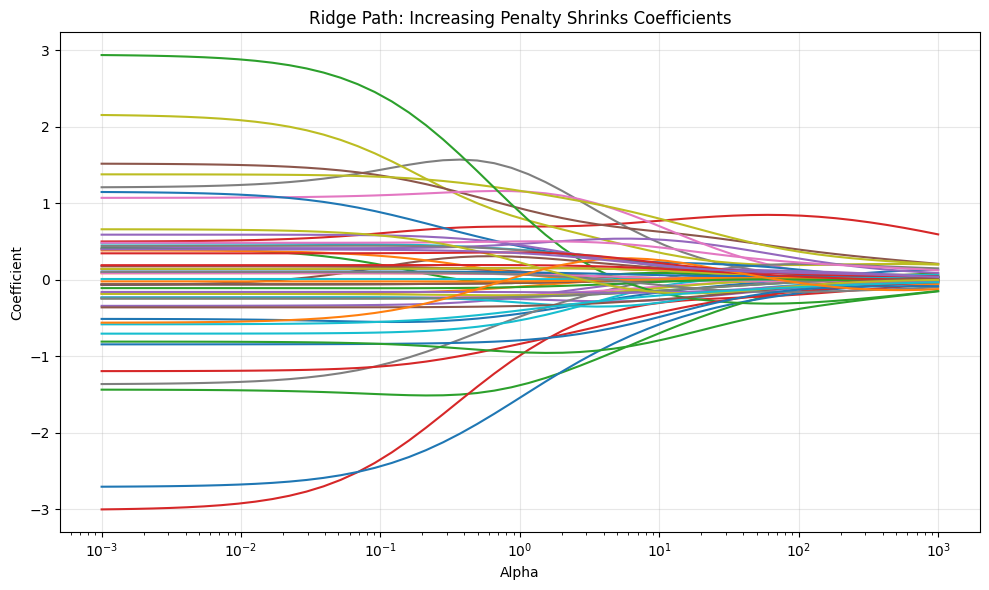

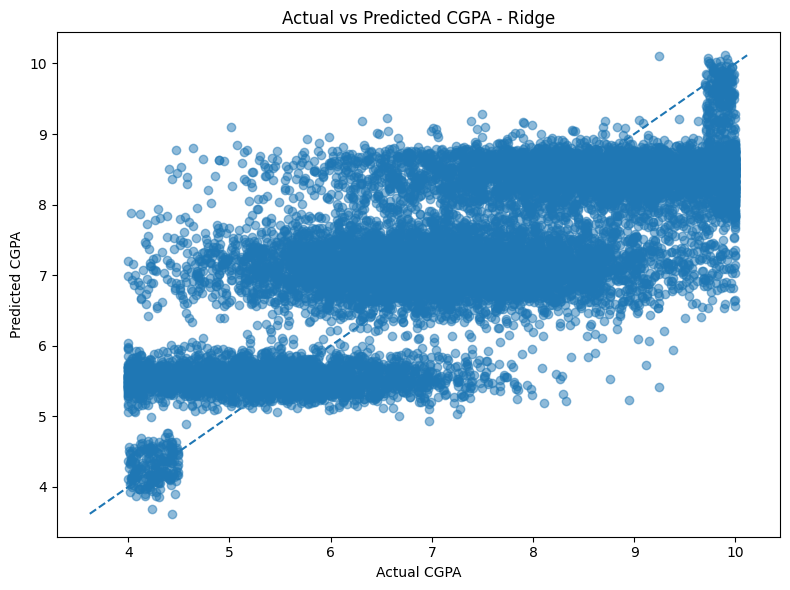


STUDENT PREDICTION
Predicted CGPA: 10.0

Model comparison saved as:
student_prediction_model_results.csv

EXECUTION COMPLETED SUCCESSFULLY


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

uploaded = files.upload()

csv_files = [
    name for name in uploaded.keys()
    if name.lower().endswith(".csv")
]

if len(csv_files) == 0:
    raise ValueError("No CSV file uploaded.")

filename = csv_files[0]

df = pd.read_csv(filename)

print("Dataset uploaded successfully:", filename)
print("\nDataset Shape:", df.shape)

base = [
    "AttendancePercent",
    "HistoryOfBacklogs",
    "Internships",
    "CodingTestScore",
    "SoftSkillsRating"
]

target = "CGPA"

required = base + [target]

missing = [
    col for col in required
    if col not in df.columns
]

if missing:
    raise ValueError(
        "Missing columns: " + str(missing)
    )

for col in base:

    if df[col].dtype == "object":

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({
                "yes": 1,
                "no": 0,
                "true": 1,
                "false": 0
            })
        )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df[target] = pd.to_numeric(
    df[target],
    errors="coerce"
)

print("\nMissing values before cleaning:")

print(
    df[required].isnull().sum()
)

df_model = df[
    required
].dropna().copy()

print(
    "\nRows available for prediction:",
    len(df_model)
)

if len(df_model) == 0:
    raise ValueError(
        "No valid rows remain after cleaning. Check the dataset column values."
    )

X = df_model[base]

y = df_model[target].values

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(
    "\nTraining samples:",
    len(Xtr)
)

print(
    "Testing samples:",
    len(Xte)
)

poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

Xtr_poly = poly.fit_transform(Xtr)

Xte_poly = poly.transform(Xte)

print(
    "\nFeatures after polynomial expansion:",
    Xtr_poly.shape[1]
)

sc = StandardScaler()

Xtr_scaled = sc.fit_transform(
    Xtr_poly
)

Xte_scaled = sc.transform(
    Xte_poly
)

models = [
    ("OLS", LinearRegression()),
    ("Ridge L2", Ridge(alpha=10)),
    ("Lasso L1", Lasso(
        alpha=0.01,
        max_iter=20000
    )),
    ("ElasticNet", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=20000
    ))
]

print("\n==============================================")
print("MODEL COMPARISON")
print("==============================================")

results = []

for name, model in models:

    model.fit(
        Xtr_scaled,
        ytr
    )

    train_pred = model.predict(
        Xtr_scaled
    )

    test_pred = model.predict(
        Xte_scaled
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            ytr,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            yte,
            test_pred
        )
    )

    train_r2 = r2_score(
        ytr,
        train_pred
    )

    test_r2 = r2_score(
        yte,
        test_pred
    )

    non_zero = int(
        np.sum(
            np.abs(model.coef_) > 1e-6
        )
    )

    results.append([
        name,
        train_rmse,
        test_rmse,
        train_r2,
        test_r2,
        non_zero
    ])

    print(
        f"{name:12s} "
        f"train RMSE={train_rmse:.4f} "
        f"test RMSE={test_rmse:.4f} "
        f"gap={test_rmse - train_rmse:+.4f} "
        f"R²={test_r2:.4f} "
        f"kept={non_zero}/{Xtr_poly.shape[1]}"
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
        "Non_Zero_Coefficients"
    ]
)

print("\n==============================================")
print("RESULTS TABLE")
print("==============================================")

print(
    results_df.round(4).to_string(
        index=False
    )
)

alphas = np.logspace(
    -3,
    3,
    50
)

best = RidgeCV(
    alphas=alphas,
    cv=5
)

best.fit(
    Xtr_scaled,
    ytr
)

ridge_prediction = best.predict(
    Xte_scaled
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        yte,
        ridge_prediction
    )
)

ridge_r2 = r2_score(
    yte,
    ridge_prediction
)

print("\n==============================================")
print("RIDGE CROSS-VALIDATION")
print("==============================================")

print(
    "Best alpha:",
    round(best.alpha_, 4)
)

print(
    "Test RMSE:",
    round(ridge_rmse, 4)
)

print(
    "Test R²:",
    round(ridge_r2, 4)
)

ridge_coefficients = []

for alpha in alphas:

    ridge_model = Ridge(
        alpha=alpha
    )

    ridge_model.fit(
        Xtr_scaled,
        ytr
    )

    ridge_coefficients.append(
        ridge_model.coef_
    )

ridge_coefficients = np.array(
    ridge_coefficients
)

plt.figure(figsize=(10, 6))

plt.plot(
    alphas,
    ridge_coefficients
)

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("Coefficient")

plt.title(
    "Ridge Path: Increasing Penalty Shrinks Coefficients"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    yte,
    ridge_prediction,
    alpha=0.5
)

plt.xlabel("Actual CGPA")

plt.ylabel("Predicted CGPA")

plt.title(
    "Actual vs Predicted CGPA - Ridge"
)

minimum = min(
    yte.min(),
    ridge_prediction.min()
)

maximum = max(
    yte.max(),
    ridge_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.tight_layout()

plt.show()

def predict_student_cgpa(
    attendance,
    backlogs,
    internships,
    coding_score,
    soft_skills
):

    student = pd.DataFrame(
        [[
            attendance,
            backlogs,
            internships,
            coding_score,
            soft_skills
        ]],
        columns=base
    )

    student_poly = poly.transform(
        student
    )

    student_scaled = sc.transform(
        student_poly
    )

    prediction = best.predict(
        student_scaled
    )[0]

    prediction = np.clip(
        prediction,
        0,
        10
    )

    return prediction

predicted_cgpa = predict_student_cgpa(
    attendance=85,
    backlogs=0,
    internships=2,
    coding_score=80,
    soft_skills=8
)

print("\n==============================================")
print("STUDENT PREDICTION")
print("==============================================")

print(
    "Predicted CGPA:",
    round(predicted_cgpa, 2)
)

results_df.to_csv(
    "student_prediction_model_results.csv",
    index=False
)

print(
    "\nModel comparison saved as:"
)

print(
    "student_prediction_model_results.csv"
)

print("\n==============================================")
print("EXECUTION COMPLETED SUCCESSFULLY")
print("==============================================")